
  Processing magnetic model: JF12


/tmp/ipykernel_13446/1966072524.py:93: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  for chunk in pd.read_csv(
/tmp/ipykernel_13446/1966072524.py:181: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  dmap = hp.smoothing(dmap, fwhm=np.radians(fwhm_deg), verbose=False)


Cluster masking is DISABLED.

  Processing magnetic model: KST24


/tmp/ipykernel_13446/1966072524.py:93: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  for chunk in pd.read_csv(
/tmp/ipykernel_13446/1966072524.py:181: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  dmap = hp.smoothing(dmap, fwhm=np.radians(fwhm_deg), verbose=False)


Cluster masking is DISABLED.
Saved combined 2×2 figure to ../plots/combined_2x2_JF12_KST24_R5.png


/tmp/ipykernel_13446/1966072524.py:495: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


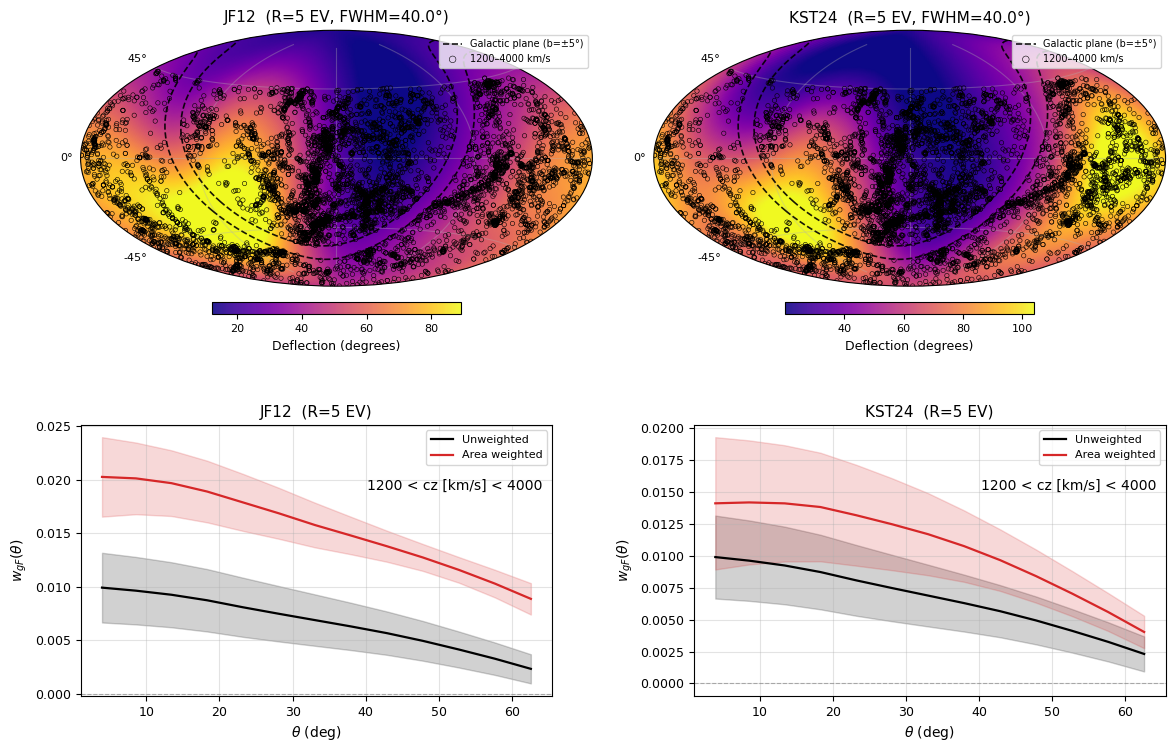

In [4]:
"""
Cleaned and modularized galaxy-flux correlation script with optional galaxy weights
(applies JF12/KST24/UF23 deflection map-derived weights to galaxies only).

Usage:
  - Edit file paths at the top if needed.
  - Run in an environment with treecorr, healpy, astropy, pandas, numpy, matplotlib.

Notes:
  - The `compute_weight_from_deflection` function is a placeholder: replace with
    the exact mapping you want from deflection to galaxy weight.
  - This script uses a deterministic subset of randoms and a fixed set of
    patch_centers so weighted/unweighted runs are consistent.
  - Local cluster masking: regions around clusters in Local_Clusters_z0.055.txt
    can be optionally excluded from galaxies, flux points, and randoms using
    the Rang column (angular radius in degrees) as the exclusion radius.
  - Magnetic field model can be chosen: "JF12", "KST24", or "UF23".
  - Running main() produces a 2x2 figure:
      top-left:  JF12 deflection map   top-right:  KST24 deflection map
      bot-left:  JF12 correlation      bot-right:  KST24 correlation
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors as mcolors
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import healpy as hp
import treecorr
from astropy.io import ascii


# --------------------------- Configuration ---------------------------
class Config:
    """Configuration parameters for the analysis."""
    GLADE_FILE   = "../data/GLADE_zhelio_lt0.1_dL_lt300.txt"
    FLUX_FILE    = "../data/Auger/flux_a8_lb.dat"
    CLUSTER_FILE          = "../data/Local_Clusters_z0.055.txt"
    CLUSTER_RADIUS_FACTOR = 10.0   # multiply Rang by this before masking
    PLOTS_DIR    = "../plots"

    # Magnetic field model selection
    MAGNETIC_MODEL = "JF12"   # options: "JF12", "KST24", "UF23"
    # File mapping
    DEFL_FILES = {
        "JF12":   "../data/deflexiones_R2R5R8_final.txt",
        "KST24":  "../data/deflexiones_R2R5R8_final_KST24Field.txt",
        "UF23":   "../data/deflexiones_R2R5R8_final_UF23Field.txt",
    }
    DEFL_FILE = DEFL_FILES[MAGNETIC_MODEL]

    # Local cluster mask toggle
    USE_CLUSTER_MASK = False   # set False to disable cluster masking

    FWHM_DEG        = 40.0   # smoothing for deflection map
    RIGIDITY        = 5      # rigidity for deflection map
    N_RAND_PER_GAL  = 100    # number of randoms per galaxy
    MIN_CZ          = 1200
    MAX_CZ          = 4000
    MB_CUT          = -18.0
    MAX_DEC         = 45.0

    # TreeCorr configuration (NK correlation)
    TC_CONFIG = {
        "min_sep"            : 1,
        "max_sep"            : 65.,
        "nbins"              : 13,
        "sep_units"          : 'degree',
        "bin_type"           : 'Linear',
        "brute"              : False,
        "metric"             : 'Arc',
        "var_method"         : 'jackknife',
        "cross_patch_weight" : 'simple',
    }


# --------------------------- Data Loading Functions ---------------------------
def read_GLADE(cols_to_use, cz_min=Config.MIN_CZ, dL_max=200,
               filename=Config.GLADE_FILE):
    """Read and filter GLADE catalog."""
    from get_masks import get_milkyway_mask

    c         = 299792.458
    chunksize = 200_000

    with open(filename, 'r') as f:
        header = f.readline().lstrip('#').split()

    filtered_chunks = []

    for chunk in pd.read_csv(
            filename,
            delim_whitespace=True,
            names=header,
            usecols=cols_to_use,
            skiprows=1,
            chunksize=chunksize):

        chunk = chunk[chunk["dist_flag"] != 0]
        chunk["cz"] = c * chunk["z_cmb"]
        chunk = chunk[(chunk["cz"] > cz_min) & (chunk["d_L"] < dL_max)]
        mask  = (np.isfinite(chunk["B"])   & np.isfinite(chunk["d_L"]) &
                 np.isfinite(chunk["RA"])  & np.isfinite(chunk["Dec"]))
        filtered_chunks.append(chunk.loc[mask])

    df        = pd.concat(filtered_chunks, ignore_index=True)
    df["M_B"] = df["B"] - 5 * np.log10(df["d_L"]) - 25

    # Apply Milky Way mask and dec cut
    df = df.iloc[get_milkyway_mask(df["RA"].values, df["Dec"].values)]
    df = df[df['Dec'] < Config.MAX_DEC]

    return df


def generate_randoms(N_total, dec_min=-90, dec_max=Config.MAX_DEC,
                     oversampling=10, max_iterations=20):
    """
    Generate random catalog with Milky Way mask.

    Draws `oversampling * N_total` candidates per iteration and accumulates
    until at least N_total points survive the mask.  The large default
    oversampling factor (10x) means a single iteration is almost always
    sufficient, but the loop provides a safety net when secondary masks
    (deflection map, cluster masking) further reduce the pool after this
    function returns.
    """
    from get_masks import get_milkyway_mask

    sin_min = np.sin(np.radians(dec_min))
    sin_max = np.sin(np.radians(dec_max))

    ra_list   = []
    dec_list  = []
    collected = 0

    for _ in range(max_iterations):
        n_draw      = int(N_total * oversampling)
        rand_ra     = np.random.uniform(0, 360, n_draw)
        rand_sindec = np.random.uniform(sin_min, sin_max, n_draw)
        rand_dec    = np.degrees(np.arcsin(rand_sindec))

        mask = get_milkyway_mask(rand_ra, rand_dec)
        ra_list.append(rand_ra[mask])
        dec_list.append(rand_dec[mask])
        collected += int(mask.sum())

        if collected >= N_total:
            break
    else:
        raise ValueError(
            f"Could not generate {N_total} randoms after {max_iterations} "
            "iterations. Check your masks or increase oversampling.")

    rand_ra  = np.concatenate(ra_list)[:N_total]
    rand_dec = np.concatenate(dec_list)[:N_total]
    return rand_ra, rand_dec


def load_deflection_map(rigidity=8, defl_file=Config.DEFL_FILE,
                        fwhm_deg=Config.FWHM_DEG):
    """Load and smooth deflection map."""
    data = ascii.read(defl_file)
    # Try to read pixel IDs from 'pixid' column; fallback to sequential indices
    if 'pixid' in data.colnames:
        pixel_ids = np.asarray(data['pixid'], dtype=int)
    else:
        # Some older files may not have explicit pixid; assume order matches HEALPix
        pixel_ids = np.arange(len(data))

    deflection_data = np.asarray(data[f'deflexion(deg)_R{int(rigidity)}'], dtype=float)

    npix  = int(np.max(pixel_ids)) + 1
    nside = hp.npix2nside(npix)
    dmap  = np.full(npix, hp.UNSEEN, dtype=float)
    dmap[pixel_ids] = deflection_data

    if fwhm_deg and fwhm_deg > 0:
        dmap = hp.smoothing(dmap, fwhm=np.radians(fwhm_deg), verbose=False)

    return dmap, nside


def load_flux_data(flux_file=Config.FLUX_FILE):
    """Load flux catalog."""
    flux_cat             = np.loadtxt(flux_file)
    flux_dec, flux_ra, flux_val = flux_cat[:, 0], flux_cat[:, 1], flux_cat[:, 2]
    return flux_ra, flux_dec, flux_val


# --------------------------- Cluster Masking ---------------------------
def load_cluster_mask(cluster_file=Config.CLUSTER_FILE,
                      cz_min=Config.MIN_CZ, cz_max=Config.MAX_CZ,
                      max_dec=Config.MAX_DEC,
                      radius_factor=Config.CLUSTER_RADIUS_FACTOR):
    """
    Read the local-cluster catalog, apply all sky/redshift cuts, and return
    the surviving exclusion regions.
    """
    from get_masks import get_milkyway_mask

    C_KMS = 299792.458

    data = ascii.read(cluster_file)
    print(f"Loaded {len(data)} clusters from {cluster_file}")

    data = data[np.abs(np.array(data['DEJ2000'], dtype=float)) <= max_dec]
    cz   = np.array(data['z'], dtype=float) * C_KMS
    data = data[(cz >= cz_min) & (cz <= cz_max)]

    ras  = np.array(data['RAJ2000'], dtype=float)
    decs = np.array(data['DEJ2000'], dtype=float)
    mw_indices        = get_milkyway_mask(ras, decs)
    mw_bool           = np.zeros(len(data), dtype=bool)
    mw_bool[mw_indices] = True
    data              = data[mw_bool]

    clusters = []
    for row in data:
        clusters.append({
            'ra'         : float(row['RAJ2000']),
            'dec'        : float(row['DEJ2000']),
            'radius'     : float(row['Rang']) * radius_factor,
            'radius_raw' : float(row['Rang']),
            'z'          : float(row['z']),
            'name'       : str(row['AName']).strip(),
        })

    return clusters


def apply_cluster_mask(ra, dec, clusters):
    """Return a boolean array (True = keep) for points outside every cluster."""
    if not clusters:
        return np.ones(len(ra), dtype=bool)

    ra  = np.asarray(ra,  dtype=float)
    dec = np.asarray(dec, dtype=float)
    keep = np.ones(len(ra), dtype=bool)

    ra_rad  = np.radians(ra)
    dec_rad = np.radians(dec)

    for cl in clusters:
        cl_ra  = np.radians(cl['ra'])
        cl_dec = np.radians(cl['dec'])
        r_max  = np.radians(cl['radius'])

        d_ra  = ra_rad  - cl_ra
        d_dec = dec_rad - cl_dec
        a     = np.sin(d_dec / 2)**2 + (np.cos(dec_rad) *
                np.cos(cl_dec) * np.sin(d_ra / 2)**2)
        sep   = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

        keep &= (sep > r_max)

    return keep


# --------------------------- Weight Functions ---------------------------
def compute_weight_from_deflection(defl_values):
    """Convert deflection (degrees) into weights for galaxies (normalized to mean=1)."""
    sigma = np.mean(defl_values**2)**0.5
    w_a   = 1.0 / ((sigma / 20.0)**2 + defl_values**2)
    w_a   = w_a / np.mean(w_a)

    w_b   = 1.0 / defl_values**2
    w_b   = w_b / np.mean(w_b)

    w_c   = 1.0 / (1 + (defl_values - defl_values.min()))**0.5
    w_c   = w_c / np.mean(w_c)

    w_d   = 1.0 / defl_values
    w_d   = w_d / np.mean(w_d)

    return w_a, w_b, w_c, w_d


# --------------------------- Galactic plane helper ---------------------------
def _galactic_plane_lines(b_vals=(5, -5), n=1000):
    """
    Return a list of (ra_hammer, dec_rad) arrays for Galactic latitude contours,
    with NaN breaks at RA wrap-arounds, ready to plot on a Hammer projection.
    """
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u
    except ImportError:
        return []

    l   = np.linspace(0, 360, n)
    lines = []
    for b_val in b_vals:
        coords    = SkyCoord(l=l*u.degree, b=b_val*u.degree,
                             frame='galactic').transform_to('fk5')
        ra_line   = coords.ra.degree
        dec_line  = coords.dec.degree
        ra_h      = np.radians(-ra_line + 180.0)
        dec_h     = np.radians(dec_line)
        diff      = np.abs(np.diff(ra_h))
        jump_idx  = np.where(diff > 5.0)[0] + 1
        ra_plot   = np.insert(ra_h,  jump_idx, np.nan)
        dec_plot  = np.insert(dec_h, jump_idx, np.nan)
        lines.append((ra_plot, dec_plot))
    return lines


# --------------------------- Axes-level plotting helpers ------------------
def _draw_deflection_map_on_ax(ax, dmap, model_label, fwhm_deg,
                                galaxies=None, rigidity=5):
    """
    Draw a smoothed GMF deflection map on an existing Hammer-projection Axes.

    Parameters
    ----------
    ax          : matplotlib Axes (projection='hammer')
    dmap        : HEALPix array
    model_label : str, e.g. 'JF12' or 'KST24'
    fwhm_deg    : float, smoothing FWHM used (for title)
    galaxies    : DataFrame with 'RA' and 'Dec' columns, or None
    rigidity    : int/float, rigidity value used (for title)
    """
    mask  = dmap != hp.UNSEEN
    npix  = len(dmap)
    nside = hp.npix2nside(npix)

    theta, phi = hp.pix2ang(nside, np.arange(npix)[mask])
    dec = 90 - np.degrees(theta)
    ra  = np.degrees(phi)

    vmin = np.percentile(dmap[mask], 5)
    vmax = np.percentile(dmap[mask], 95)

    ra_h  = np.radians(-ra + 180.0)
    dec_h = np.radians(dec)

    sc = ax.scatter(ra_h, dec_h, c=dmap[mask], s=6, cmap='plasma',
                    norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
                    edgecolor='none', alpha=0.9, rasterized=True)

    # Galactic plane lines
    for i, (ra_line, dec_line) in enumerate(_galactic_plane_lines()):
        lbl = 'Galactic plane (b=±5°)' if i == 0 else '_nolegend_'
        ax.plot(ra_line, dec_line, 'k--', lw=1.2, alpha=0.9, label=lbl)

    # Overlay galaxies
    if galaxies is not None and len(galaxies) > 0:
        gra_h = np.radians(-galaxies['RA'] + 180.0)
        gdec_h = np.radians(galaxies['Dec'])
        ax.scatter(gra_h, gdec_h, s=10, facecolor='none',
                   edgecolor='k', linewidth=0.4,
                   label=f'{Config.MIN_CZ}–{Config.MAX_CZ} km/s', zorder=10)

    # Axes cosmetics
    xticks_deg = [270, 180, 90]
    ax.set_xticks(-np.radians(xticks_deg) + np.pi)
    ax.set_xticklabels([f'{d}°' for d in xticks_deg], fontsize=8)
    ax.set_yticks(np.radians([-45, 0, 45]))
    ax.set_yticklabels(['-45°', '0°', '45°'], fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.set_title(f'{model_label}  (R={rigidity} EV, FWHM={fwhm_deg}°)', fontsize=11)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                        pad=0.05, fraction=0.04, shrink=0.85)
    cbar.set_label('Deflection (degrees)', fontsize=9)
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    cbar.ax.tick_params(labelsize=8)

    if galaxies is not None and len(galaxies) > 0:
        ax.legend(loc='upper right', fontsize=7, markerscale=1.5)


def _draw_correlation_on_ax(ax, results, model_label, rigidity=5):
    """
    Draw unweighted and area-weighted correlation functions on an existing Axes.

    Parameters
    ----------
    ax          : matplotlib Axes
    results     : dict with keys 'unweighted' and 'area', each a
                  (meanr, xi, varxi, nk, rk) tuple
    model_label : str for the panel title
    rigidity    : int/float for the panel title
    """
    styles = {
        'unweighted': ('Unweighted',    'k',  '-'),
        'area'      : ('Area weighted', 'C3', '-'),
    }

    for key, (label, color, ls) in styles.items():
        if key not in results:
            continue
        meanr, xi, varxi = results[key][:3]
        ax.fill_between(meanr,
                        xi - np.sqrt(varxi),
                        xi + np.sqrt(varxi),
                        color=color, alpha=0.18)
        ax.plot(meanr, xi, color=color, ls=ls, label=label, lw=1.6)

    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlabel(r'$\theta$ (deg)', fontsize=10)
    ax.set_ylabel(r'$w_{gF}(\theta)$', fontsize=10)
    ax.set_title(f'{model_label}  (R={rigidity} EV)', fontsize=11)
    ax.text(0.98, 0.8,
            f'{Config.MIN_CZ} < cz [km/s] < {Config.MAX_CZ}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.tick_params(labelsize=9)


# --------------------------- Combined 2×2 plot ---------------------------
def plot_combined_2x2(model_data, savepath=None):
    """
    Produce a 2×2 figure:
      row 0 : deflection maps  (col 0 = JF12,  col 1 = KST24)
      row 1 : correlation fns  (col 0 = JF12,  col 1 = KST24)

    Parameters
    ----------
    model_data : dict keyed by model name (e.g. 'JF12', 'KST24'), each value
                 is a dict with keys:
                   'dmap'     : HEALPix deflection array (smoothed)
                   'galaxies' : filtered galaxy DataFrame
                   'results'  : correlation results dict ('unweighted', 'area')
    savepath   : optional file path to save the figure
    """
    models = list(model_data.keys())   # preserves insertion order (Python ≥3.7)
    n_cols = len(models)               # 2

    plt.rcParams.update({
        'font.size'      : 10,
        'axes.labelsize' : 10,
        'axes.titlesize' : 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
    })

    fig = plt.figure(figsize=(14, 9))

    # Two rows: top for maps (Hammer projection), bottom for correlations (rectilinear)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              hspace=0.38,
                              height_ratios=[1.15, 1.0])

    top_gs  = gridspec.GridSpecFromSubplotSpec(1, n_cols, subplot_spec=outer[0],
                                               wspace=0.12)
    bot_gs  = gridspec.GridSpecFromSubplotSpec(1, n_cols, subplot_spec=outer[1],
                                               wspace=0.30)

    for col, model in enumerate(models):
        data = model_data[model]

        # ── Top row: deflection map ──────────────────────────────────────────
        ax_map = fig.add_subplot(top_gs[col], projection='hammer')
        _draw_deflection_map_on_ax(
            ax_map,
            dmap        = data['dmap'],
            model_label = model,
            fwhm_deg    = Config.FWHM_DEG,
            galaxies    = data.get('galaxies'),
            rigidity    = Config.RIGIDITY,
        )

        # ── Bottom row: correlation function ─────────────────────────────────
        ax_corr = fig.add_subplot(bot_gs[col])
        _draw_correlation_on_ax(
            ax_corr,
            results     = data['results'],
            model_label = model,
            rigidity    = Config.RIGIDITY,
        )

    # Row labels in the left margin
    # fig.text(0.01, 0.75, 'GMF deflection maps',
    #          va='center', rotation='vertical', fontsize=11, color='#333333')
    # fig.text(0.01, 0.28, 'Cross-correlations',
    #          va='center', rotation='vertical', fontsize=11, color='#333333')

    # fig.suptitle(
    #     f'GMF model comparison  —  R = {Config.RIGIDITY} EV  |  '
    #     f'{Config.MIN_CZ} < cz < {Config.MAX_CZ} km/s  |  '
    #     f'$M_B$ < {Config.MB_CUT}',
    #     fontsize=12, y=0.995,
    # )

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
        print(f"Saved combined 2×2 figure to {savepath}")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


# --------------------------- Correlation Computation ---------------------------
def compute_correlation_fixed(gal_ra, gal_dec, gal_weights,
                               rand_ra, rand_dec, rand_weights,
                               flux_ra, flux_dec, flux_val,
                               patch_centers, config=Config.TC_CONFIG):
    """Compute NK correlation with fixed patch centers."""
    gcat = treecorr.Catalog(
        ra=gal_ra, dec=gal_dec, w=gal_weights,
        ra_units='deg', dec_units='deg', patch_centers=patch_centers,
    )

    rand_cat = treecorr.Catalog(
        ra=rand_ra, dec=rand_dec, w=rand_weights,
        ra_units='deg', dec_units='deg', patch_centers=patch_centers,
    )

    fcat = treecorr.Catalog(
        ra=flux_ra, dec=flux_dec, k=flux_val,
        ra_units='deg', dec_units='deg',
    )

    nk = treecorr.NKCorrelation(config)
    rk = treecorr.NKCorrelation(config)

    nk.process(gcat, fcat)
    rk.process(rand_cat, fcat)

    xi    = nk.xi / rk.xi - 1
    varxi = nk.varxi / (rk.xi ** 2)

    return nk.meanr, xi, varxi, nk, rk


# --------------------------- Main Analysis Class ---------------------------
class GalaxyFluxAnalyzer:
    """Main analysis class for galaxy-flux correlation."""

    def __init__(self, magnetic_model="JF12"):
        self.magnetic_model = magnetic_model
        self.defl_file      = Config.DEFL_FILES[magnetic_model]

    def load_and_filter_galaxies(self):
        """Load and filter galaxy catalog."""
        cols  = ["GLADE_no", "RA", "Dec", "z_cmb", "B", "d_L", "dist_flag"]
        gxs   = read_GLADE(cols)

        if gxs['RA'].max() <= 2 * np.pi:
            gxs['RA']  = np.degrees(gxs['RA'])
            gxs['Dec'] = np.degrees(gxs['Dec'])

        gxs   = gxs[gxs['M_B'] < Config.MB_CUT]

        gxs_K = gxs[(gxs['cz'] >= Config.MIN_CZ) &
                    (gxs['cz'] <= Config.MAX_CZ)].reset_index(drop=True)

        return gxs_K

    def apply_deflection_mask(self, ra, dec, deflection_map, nside):
        """Apply deflection map mask to coordinates."""
        theta       = np.radians(90 - dec)
        phi         = np.radians(ra)
        pix         = hp.ang2pix(nside, theta, phi)
        defl_values = deflection_map[pix]
        valid       = defl_values != hp.UNSEEN
        return valid, defl_values[valid] if valid.any() else np.array([])

    def process_catalogs(self):
        """
        Main processing pipeline for one magnetic field model.

        Returns
        -------
        dict with keys:
          'dmap'     : smoothed HEALPix deflection map
          'galaxies' : filtered galaxy DataFrame
          'results'  : correlation results dict ('unweighted', 'area')
        """
        print(f"\n{'='*60}")
        print(f"  Processing magnetic model: {self.magnetic_model}")
        print(f"{'='*60}")

        # Load galaxies
        gxs_K = self.load_and_filter_galaxies()

        # Load flux data
        flux_ra, flux_dec, flux_val = load_flux_data()

        # Load deflection map for this model
        deflection_map, nside = load_deflection_map(
            rigidity=Config.RIGIDITY,
            defl_file=self.defl_file,
            fwhm_deg=Config.FWHM_DEG,
        )

        # Load cluster exclusion regions if mask is enabled
        if Config.USE_CLUSTER_MASK:
            clusters = load_cluster_mask(Config.CLUSTER_FILE,
                                         radius_factor=Config.CLUSTER_RADIUS_FACTOR)
        else:
            clusters = []
            print("Cluster masking is DISABLED.")

        # Apply cluster mask to galaxies
        if Config.USE_CLUSTER_MASK and clusters:
            keep_gal  = apply_cluster_mask(
                gxs_K['RA'].values, gxs_K['Dec'].values, clusters)
            n_before  = len(gxs_K)
            gxs_K     = gxs_K[keep_gal].reset_index(drop=True)
            print(f"Galaxies: {n_before} -> {len(gxs_K)} after cluster masking")

        # Apply deflection mask to galaxies
        valid_gal, gal_defl = self.apply_deflection_mask(
            gxs_K['RA'].values, gxs_K['Dec'].values, deflection_map, nside)
        gxs_K = gxs_K[valid_gal].reset_index(drop=True)

        # Apply cluster mask to flux points
        if Config.USE_CLUSTER_MASK and clusters:
            keep_flux = apply_cluster_mask(flux_ra, flux_dec, clusters)
            flux_ra   = flux_ra[keep_flux]
            flux_dec  = flux_dec[keep_flux]
            flux_val  = flux_val[keep_flux]

        # Apply deflection mask to flux points
        valid_flux, _ = self.apply_deflection_mask(
            flux_ra, flux_dec, deflection_map, nside)
        flux_ra  = flux_ra[valid_flux]
        flux_dec = flux_dec[valid_flux]
        flux_val = flux_val[valid_flux]

        # Generate and mask randoms
        N_rand_needed = len(gxs_K) * Config.N_RAND_PER_GAL
        rand_ra_all, rand_dec_all = generate_randoms(N_rand_needed)

        valid_rand, _ = self.apply_deflection_mask(
            rand_ra_all, rand_dec_all, deflection_map, nside)
        rand_ra_all  = rand_ra_all[valid_rand]
        rand_dec_all = rand_dec_all[valid_rand]

        if Config.USE_CLUSTER_MASK and clusters:
            keep_rand    = apply_cluster_mask(rand_ra_all, rand_dec_all, clusters)
            rand_ra_all  = rand_ra_all[keep_rand]
            rand_dec_all = rand_dec_all[keep_rand]

        # Top up randoms if needed
        while len(rand_ra_all) < N_rand_needed:
            n_extra          = (N_rand_needed - len(rand_ra_all)) * 5
            extra_ra, extra_dec = generate_randoms(n_extra)
            valid_extra, _   = self.apply_deflection_mask(
                extra_ra, extra_dec, deflection_map, nside)
            extra_ra         = extra_ra[valid_extra]
            extra_dec        = extra_dec[valid_extra]
            if Config.USE_CLUSTER_MASK and clusters:
                keep_extra   = apply_cluster_mask(extra_ra, extra_dec, clusters)
                extra_ra     = extra_ra[keep_extra]
                extra_dec    = extra_dec[keep_extra]
            rand_ra_all      = np.concatenate([rand_ra_all,  extra_ra])
            rand_dec_all     = np.concatenate([rand_dec_all, extra_dec])

        rand_ra_sub  = np.asarray(rand_ra_all[:N_rand_needed], dtype=float)
        rand_dec_sub = np.asarray(rand_dec_all[:N_rand_needed], dtype=float)

        # Prepare arrays
        gal_ra   = np.asarray(gxs_K['RA'],  dtype=float)
        gal_dec  = np.asarray(gxs_K['Dec'], dtype=float)
        flux_ra  = np.asarray(flux_ra,  dtype=float)
        flux_dec = np.asarray(flux_dec, dtype=float)
        flux_val = np.asarray(flux_val, dtype=float)

        # gal_defl is already aligned with gxs_K after apply_deflection_mask;
        # pass the raw (pre-secondary-valid) slice carefully:
        _, w_gal_b, _, _ = compute_weight_from_deflection(gal_defl)
        w_rand = np.ones(len(rand_ra_sub), dtype=float)

        # TreeCorr patch setup
        npatch = 93
        base   = treecorr.Catalog(
            ra=np.concatenate([gal_ra, rand_ra_sub]),
            dec=np.concatenate([gal_dec, rand_dec_sub]),
            ra_units='deg', dec_units='deg', npatch=npatch,
        )
        patch_centers = base.patch_centers

        # Compute correlations
        results = {}

        results['unweighted'] = compute_correlation_fixed(
            gal_ra, gal_dec, None,
            rand_ra_sub, rand_dec_sub, None,
            flux_ra, flux_dec, flux_val,
            patch_centers,
        )

        results['area'] = compute_correlation_fixed(
            gal_ra, gal_dec, w_gal_b,
            rand_ra_sub, rand_dec_sub, w_rand,
            flux_ra, flux_dec, flux_val,
            patch_centers,
        )

        return {
            'dmap'     : deflection_map,
            'galaxies' : gxs_K,
            'results'  : results,
        }


# --------------------------- Entry Point ---------------------------
def main():
    """
    Run the full analysis for JF12 and KST24 models, then produce the
    combined 2×2 comparison figure.
    """
    models_to_run = ['JF12', 'KST24']
    model_data    = {}

    for model in models_to_run:
        analyzer           = GalaxyFluxAnalyzer(magnetic_model=model)
        model_data[model]  = analyzer.process_catalogs()

    plot_combined_2x2(
        model_data,
        savepath=f"{Config.PLOTS_DIR}/combined_2x2_JF12_KST24_R{Config.RIGIDITY}.png",
    )


if __name__ == '__main__':
    main()